<div align="center">
  <span style="color:red; font-family:Georgia; font-size:2.2em;">
    Laporan Proyek Akhir Dasar Analitika Data
  </span>
</div>

---

### Informasi Kelompok

<div class="alert alert-block alert-success">

**Nomor Kelompok:** 7  

**Anggota Kelompok:**
1. Grace Yunike Margaretha Sitorus (2306267031)  
2. Samih Bassam (2306250623)  
3. Wilman Saragih Sitio (2306161776)  
4. Reinathan Ezkhiel Kurniawan (2406397675)  

**Judul Dataset:** Student Productivity & Distraction  

**URL Dataset:**  
https://www.kaggle.com/datasets/misterprofessor/student-productivity-distraction-dataset-20000

</div>

---

Laporan ini dibuat sebagai eksplorasi menyeluruh menggunakan kerangka standar **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) untuk menganalisis dataset *Student Productivity & Distraction*.  

CRISP-DM menyediakan pendekatan terstruktur yang terdiri dari 6 tahapan:

---

### Tahapan CRISP-DM

- **Business Understanding**  
  Menentukan tujuan bisnis, menilai situasi, serta merumuskan tujuan teknis machine learning.

- **Data Understanding**  
  Mengumpulkan data awal, mendeskripsikan data, melakukan eksplorasi, dan memverifikasi kualitas data.

- **Data Preparation**  
  Melakukan seleksi data, pembersihan, konstruksi fitur, integrasi, dan formatting.

- **Modeling**  
  Memilih teknik, merancang skenario pengujian, membangun model, dan melakukan evaluasi awal.

- **Evaluation**  
  Mengevaluasi hasil model, melakukan review proses, dan menentukan langkah selanjutnya.

- **Deployment**  
  Menyusun rencana deployment, monitoring, serta penyusunan laporan akhir.

---

# Daftar Isi

1. [Business Understanding](#Businessunderstanding)
2. [Data Understanding](#Dataunderstanding)
3. [Data Preparation](#Datapreparation)
4. [Exploratory Data Analysis](#EDA)
5. [Feature Selection](#FeatureSelection)
6. [Modelling](#Modelling)
7. [Evaluation & Conclusion](#Evaluation)


---

# 1. Stage One — Business Understanding <a class="anchor" id="Businessunderstanding"></a>
Tahap pertama CRISP-DM adalah memahami apa yang ingin dicapai dari **perspektif bisnis/klinis**.


## 1.1 Assess the Current Situation

<div class="alert alert-block alert-success">

**Background:**
Produktivitas mahasiswa merupakan salah satu indikator penting bagi keberhasilan akademik, retensi studi, dan kesejahteraan mahasiswa. Di sisi lain, distraksi digital seperti penggunaan ponsel, media sosial, YouTube, dan gaming semakin dominan dalam keseharian mahasiswa. Kondisi ini menyulitkan pihak kampus untuk menentukan faktor mana yang paling mendorong atau justru menurunkan produktivitas belajar secara terukur.

**Pemilihan Target Variable (`productivity_score`):**
Target variable yang dipilih adalah `productivity_score` karena variabel ini merepresentasikan keluaran utama yang paling dekat dengan tujuan institusional proyek, yaitu memahami tingkat produktivitas mahasiswa secara kuantitatif. Target ini juga didukung oleh fitur-fitur prediktor yang relevan, seperti kebiasaan belajar, kualitas tidur, kehadiran, fokus, stres, dan intensitas distraksi digital.

**Business / Clinical Objectives:**
Membangun model prediktif untuk membantu kampus **mengidentifikasi faktor yang paling berpengaruh terhadap produktivitas mahasiswa** sehingga intervensi akademik, wellbeing, dan layanan konseling dapat diprioritaskan dengan lebih tepat sasaran.

**Business Success Criteria:**
- Kampus memperoleh **minimal 3 rekomendasi aksi yang dapat diterapkan** untuk meningkatkan produktivitas mahasiswa.
- Hasil analisis cukup interpretatif untuk membantu prioritisasi intervensi terkait **fokus belajar, kebiasaan tidur, stres, dan distraksi digital**.
- Model tidak hanya akurat, tetapi juga cukup transparan untuk dijelaskan kepada pemangku kepentingan non-teknis.

</div>


### 1.1.1. Inventory of Resources

**Personnel (Data Scientists):**
1. Grace Yunike Margaretha Sitorus — Data Cleaning & Preparation
2. Samih Bassam — Feature Engineering & Selection
3. Wilman Saragih Sitio — Modeling & Evaluation
4. Reinathan Ezkhiel Kurniawan — Visualisasi & Deployment

**Data:** Dataset "Student Productivity & Distraction" dari Kaggle (20.000 records, 18 features).

**Computing Resources:** Google Colab (CPU/GPU), Laptop lokal dengan Jupyter Notebook.

**Software:** Python 3.x, Pandas, NumPy, Scikit-Learn, Seaborn, Matplotlib, Streamlit.


### 1.1.2. Requirements, Assumptions and Constraints

<div class="alert alert-block alert-success">

**Requirements:**
- Proyek diselesaikan dalam kurun waktu semester berjalan.
- Seluruh pipeline harus reproducible dan bebas data leakage.

**Assumptions:**
- Dataset sintetis namun representatif terhadap pola perilaku mahasiswa.
- Hubungan antar variabel bersifat dapat dipelajari oleh algoritma regresi.
- Tidak ada variabel penting yang hilang dari dataset.

**Constraints:**
- Data bersifat sintetis sehingga insight mungkin tidak sepenuhnya merepresentasikan perilaku stokastik manusia nyata.
- Tidak ada data temporal (time-series) sehingga analisis bersifat cross-sectional.

</div>


### 1.1.3. Risks and Contingencies
Karena proyek ini bersifat eksperimental/akademis, risiko utama adalah:
- **Overfitting** pada data sintetis → Mitigasi: Cross-Validation dan regularisasi.
- **Data leakage** → Mitigasi: Split data sebelum scaling/transformasi.


### 1.1.4. Terminology

| Istilah | Definisi |
|---------|----------|
| `productivity_score` | Skor produktivitas mahasiswa (0–100), **target variable** |
| `study_hours_per_day` | Jam belajar per hari |
| `phone_usage_hours` | Jam penggunaan ponsel per hari |
| `focus_score` | Skor kemampuan fokus mahasiswa (30–99) |
| `stress_level` | Tingkat stres (skala 1–10) |
| `total_screen_time` | **Derived feature**: total jam layar (ponsel + medsos + YouTube + gaming) |
| `study_sleep_ratio` | **Derived feature**: rasio jam belajar terhadap jam tidur |
| Winsorization | Teknik penanganan outlier dengan clamp ke batas IQR |
| Data Leakage | Kebocoran informasi test set ke proses training |


### 1.1.5. Costs and Benefits
Karena proyek ini bersifat eksperimental, tidak ada analisis biaya-manfaat finansial. Namun, benefit potensial bagi institusi adalah **efisiensi program konseling** dan **peningkatan retensi mahasiswa** melalui intervensi berbasis data.


## 1.2 What are the Desired Outputs?

<div class="alert alert-block alert-success">

**Kriteria Keberhasilan Bisnis:**
- Menghasilkan minimal 3 rekomendasi intervensi yang dapat langsung dipertimbangkan oleh kampus.
- Membantu kampus memprioritaskan program terkait **manajemen fokus belajar, kebiasaan tidur sehat, pengelolaan stres, dan pengurangan distraksi digital**.

**Kriteria Keberhasilan Machine Learning:**
- MAE (Mean Absolute Error) serendah mungkin agar error prediksi tetap kecil dalam satuan poin produktivitas.
- RMSE rendah agar model tidak sering menghasilkan error besar.
- R-squared tinggi (target internal > 0.85) agar sebagian besar variasi target berhasil dijelaskan model.
- Model final tetap stabil saat diuji ulang menggunakan **10-fold cross-validation**.

</div>


## 1.3 What Questions Are We Trying To Answer?

<div class="alert alert-block alert-success">

1. Kondisi dan gaya hidup seperti apa yang paling berkorelasi positif dengan produktivitas belajar?
2. Bagaimana pengaruh spesifik dari distraksi digital (durasi penggunaan HP, medsos, gaming) terhadap skor produktivitas?
3. Sejauh mana tingkat stres mahasiswa berinteraksi dengan fokus dan pencapaian akademik mereka?
4. Fitur turunan (*derived features*) mana yang paling efektif menangkap pola perilaku mahasiswa?
5. Algoritma regresi mana yang paling akurat dan interpretatif untuk memprediksi skor produktivitas?

</div>


---

# 2. Stage Two — Data Understanding <a class="anchor" id="Dataunderstanding"></a>
Tahap kedua CRISP-DM: memperoleh data, memahami karakteristik, dan memverifikasi kualitasnya.


## 2.1 Initial Data Report

<div class="alert alert-block alert-success">
Sumber data: <b>Kaggle — Student Productivity & Distraction Dataset</b> (20.000 records, 18 kolom).
</div>

**Informasi variabel:**

| No | Kolom | Deskripsi | Tipe | Peran |
|----|-------|-----------|------|-------|
| 1 | `student_id` | ID unik mahasiswa | Integer | Identifier |
| 2 | `age` | Usia (17–29) | Integer | Demografis |
| 3 | `gender` | Jenis kelamin (Male/Female/Other) | Kategorikal | Demografis |
| 4 | `study_hours_per_day` | Jam belajar/hari | Float | Akademik |
| 5 | `sleep_hours` | Jam tidur/hari | Float | Gaya Hidup |
| 6 | `phone_usage_hours` | Jam penggunaan ponsel/hari | Float | Distraksi |
| 7 | `social_media_hours` | Jam media sosial/hari | Float | Distraksi |
| 8 | `youtube_hours` | Jam YouTube/hari | Float | Distraksi |
| 9 | `gaming_hours` | Jam gaming/hari | Float | Distraksi |
| 10 | `breaks_per_day` | Jumlah istirahat/hari | Integer | Gaya Hidup |
| 11 | `coffee_intake_mg` | Konsumsi kafein (mg) | Integer | Gaya Hidup |
| 12 | `exercise_minutes` | Durasi olahraga (menit) | Integer | Gaya Hidup |
| 13 | `assignments_completed` | Jumlah tugas selesai | Integer | Akademik |
| 14 | `attendance_percentage` | Persentase kehadiran | Float | Akademik |
| 15 | `stress_level` | Tingkat stres (1–10) | Integer | Psikologis |
| 16 | `focus_score` | Skor fokus | Integer | Psikologis |
| 17 | `final_grade` | Nilai akhir akademik | Float | Performa |
| 18 | `productivity_score` | Skor produktivitas | Float | **TARGET** |


In [3]:
# ── Import Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
print('Libraries berhasil di-import!')


Libraries berhasil di-import!


In [4]:
# ── Load Dataset ──
!wget -O student.csv "https://www.dropbox.com/scl/fi/4taexi9t5818vpcmp55qp/student_productivity_distraction_dataset_20000.csv?rlkey=e9xdqecs7c9xswxsyye3yir0n&st=sqqtckdy&dl=1"
df = pd.read_csv('student.csv')
print(f'Dataset berhasil dimuat: {df.shape[0]} baris × {df.shape[1]} kolom')


--2026-05-08 05:30:20--  https://www.dropbox.com/scl/fi/4taexi9t5818vpcmp55qp/student_productivity_distraction_dataset_20000.csv?rlkey=e9xdqecs7c9xswxsyye3yir0n&st=sqqtckdy&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucb5818974a72d759a8551a8f11e.dl.dropboxusercontent.com/cd/0/inline/DAAza2q-4cCWukdMrbYt5qgFaCdwRI5THAW9JMMfW89cp5vJoQ7qlHw1Ld_Wpb3AHJdFOHZLrh3rcSIWkjL4HztCchyvxBRWm_zXVygPOs86m8qe8Y31dXUq9bZXIa0fdZ1wNV8d6JwXklfc2CAdm0EP/file?dl=1# [following]
--2026-05-08 05:30:21--  https://ucb5818974a72d759a8551a8f11e.dl.dropboxusercontent.com/cd/0/inline/DAAza2q-4cCWukdMrbYt5qgFaCdwRI5THAW9JMMfW89cp5vJoQ7qlHw1Ld_Wpb3AHJdFOHZLrh3rcSIWkjL4HztCchyvxBRWm_zXVygPOs86m8qe8Y31dXUq9bZXIa0fdZ1wNV8d6JwXklfc2CAdm0EP/file?dl=1
Resolving ucb5818974a72d759a8551a8f11e.dl.dropboxusercontent.com (ucb5818974a72d

## 2.2 Describe Data


In [5]:
# Tampilkan 5 data pertama
df.head()


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [6]:
# Tampilkan 5 data terakhir
df.tail()


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06
19999,20000,19,Female,3.64,6.35,8.68,0.11,5.19,1.28,8,50,70,9,40.08,9,65,72.70,30.37


In [7]:
# Dimensi dataset
print(f'Jumlah Baris  : {df.shape[0]}')
print(f'Jumlah Kolom  : {df.shape[1]}')


Jumlah Baris  : 20000
Jumlah Kolom  : 18


In [8]:
# Informasi tipe data dan non-null count
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [9]:
# Statistik deskriptif
df.describe().T


,count,mean,std,min,25%,50%,75%,max
student_id,20000.0,10000.500000,5773.647028,1.0,5000.7500,10000.500,15000.2500,20000.00
age,20000.0,23.007450,3.754890,17.0,20.0000,23.000,26.0000,29.00
study_hours_per_day,20000.0,5.254562,2.742876,0.5,2.9000,5.250,7.6400,10.00
sleep_hours,20000.0,6.517799,2.029784,3.0,4.7700,6.510,8.3100,10.00
phone_usage_hours,20000.0,6.250479,3.313082,0.5,3.3800,6.240,9.1025,12.00
social_media_hours,20000.0,4.003655,2.305154,0.0,2.0000,4.010,5.9700,8.00
youtube_hours,20000.0,2.990177,1.729815,0.0,1.4875,2.980,4.4800,6.00
gaming_hours,20000.0,2.988339,1.732803,0.0,1.4900,2.970,4.4900,6.00
breaks_per_day,20000.0,7.542400,4.016231,1.0,4.0000,8.000,11.0000,14.00
coffee_intake_mg,20000.0,249.654550,143.711231,0.0,125.0000,249.000,373.0000,499.00


In [10]:
# Tipe data per kolom
print('Tipe data per kolom:')
print(df.dtypes)
print(f'\nKolom numerik : {df.select_dtypes(include=[np.number]).shape[1]}')
print(f'Kolom kategorikal: {df.select_dtypes(include=["object"]).shape[1]}')


Tipe data per kolom:
student_id                 int64
age                        int64
gender                    object
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level               int64
focus_score                int64
final_grade              float64
productivity_score       float64
dtype: object

Kolom numerik : 17
Kolom kategorikal: 1


## 2.3 Verify Data Quality
Memeriksa kelengkapan, konsistensi, dan keakuratan data.


### 2.3.1. Missing Data


In [11]:
# Pengecekan missing values
missing = df.isnull().sum()
print('Missing values per kolom:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

# Cek placeholder tersembunyi
for col in df.columns:
    if df[col].dtype == 'object':
        suspicious = df[col].isin(['?', 'NA', 'N/A', '', ' ', 'unknown', 'null']).sum()
        if suspicious > 0:
            print(f'   {col}: {suspicious} placeholder tersembunyi ditemukan')
print('\n Tidak ditemukan missing values maupun placeholder tersembunyi.')


Missing values per kolom:
student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64

Total missing values: 0

 Tidak ditemukan missing values maupun placeholder tersembunyi.


<div class="alert alert-block alert-success">
<b>Kesimpulan Missing Data:</b> Dataset tidak memiliki missing values (0 NaN). Pengecekan placeholder tersembunyi seperti `'?'`, `'NA'`, dan string kosong juga tidak menemukan masalah. Dari sisi kelengkapan, dataset dapat dikategorikan bersih. Namun, kebersihan data tidak otomatis berarti data sudah realistis; karena dataset bersifat sintetis, temuan tetap perlu dibaca dengan hati-hati saat digeneralisasikan ke kondisi mahasiswa nyata.
</div>


### 2.3.2. Outliers

**Justifikasi pemilihan metode IQR:** Distribusi data bersifat **platikurtik** (kurtosis ≈ −1.2) dan relatif simetris (skewness ≈ 0). Meskipun Z-Score juga dapat digunakan untuk data mendekati normal, metode IQR lebih **robust** terhadap distribusi yang tidak sepenuhnya normal dan tidak terpengaruh oleh outlier itu sendiri saat menghitung batas. Selain itu, **tidak adanya missing values dan outlier ekstrem** membuktikan konsistensi data, yang secara langsung meningkatkan kepercayaan (confidence) model.


In [12]:
# Deteksi Outlier dengan metode IQR
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('student_id')

outlier_report = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'Variabel': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                           'Lower': lower, 'Upper': upper, 'Jumlah_Outlier': n_outliers})

outlier_df = pd.DataFrame(outlier_report)
print('Laporan Deteksi Outlier (Metode IQR):')
outlier_df


Laporan Deteksi Outlier (Metode IQR):


,Variabel,Q1,Q3,IQR,Lower,Upper,Jumlah_Outlier
0,age,20.0000,26.0000,6.0000,11.00000,35.00000,0
1,study_hours_per_day,2.9000,7.6400,4.7400,-4.21000,14.75000,0
2,sleep_hours,4.7700,8.3100,3.5400,-0.54000,13.62000,0
3,phone_usage_hours,3.3800,9.1025,5.7225,-5.20375,17.68625,0
4,social_media_hours,2.0000,5.9700,3.9700,-3.95500,11.92500,0
5,youtube_hours,1.4875,4.4800,2.9925,-3.00125,8.96875,0
6,gaming_hours,1.4900,4.4900,3.0000,-3.01000,8.99000,0
7,breaks_per_day,4.0000,11.0000,7.0000,-6.50000,21.50000,0
8,coffee_intake_mg,125.0000,373.0000,248.0000,-247.00000,745.00000,0
9,exercise_minutes,30.0000,90.0000,60.0000,-60.00000,180.00000,0


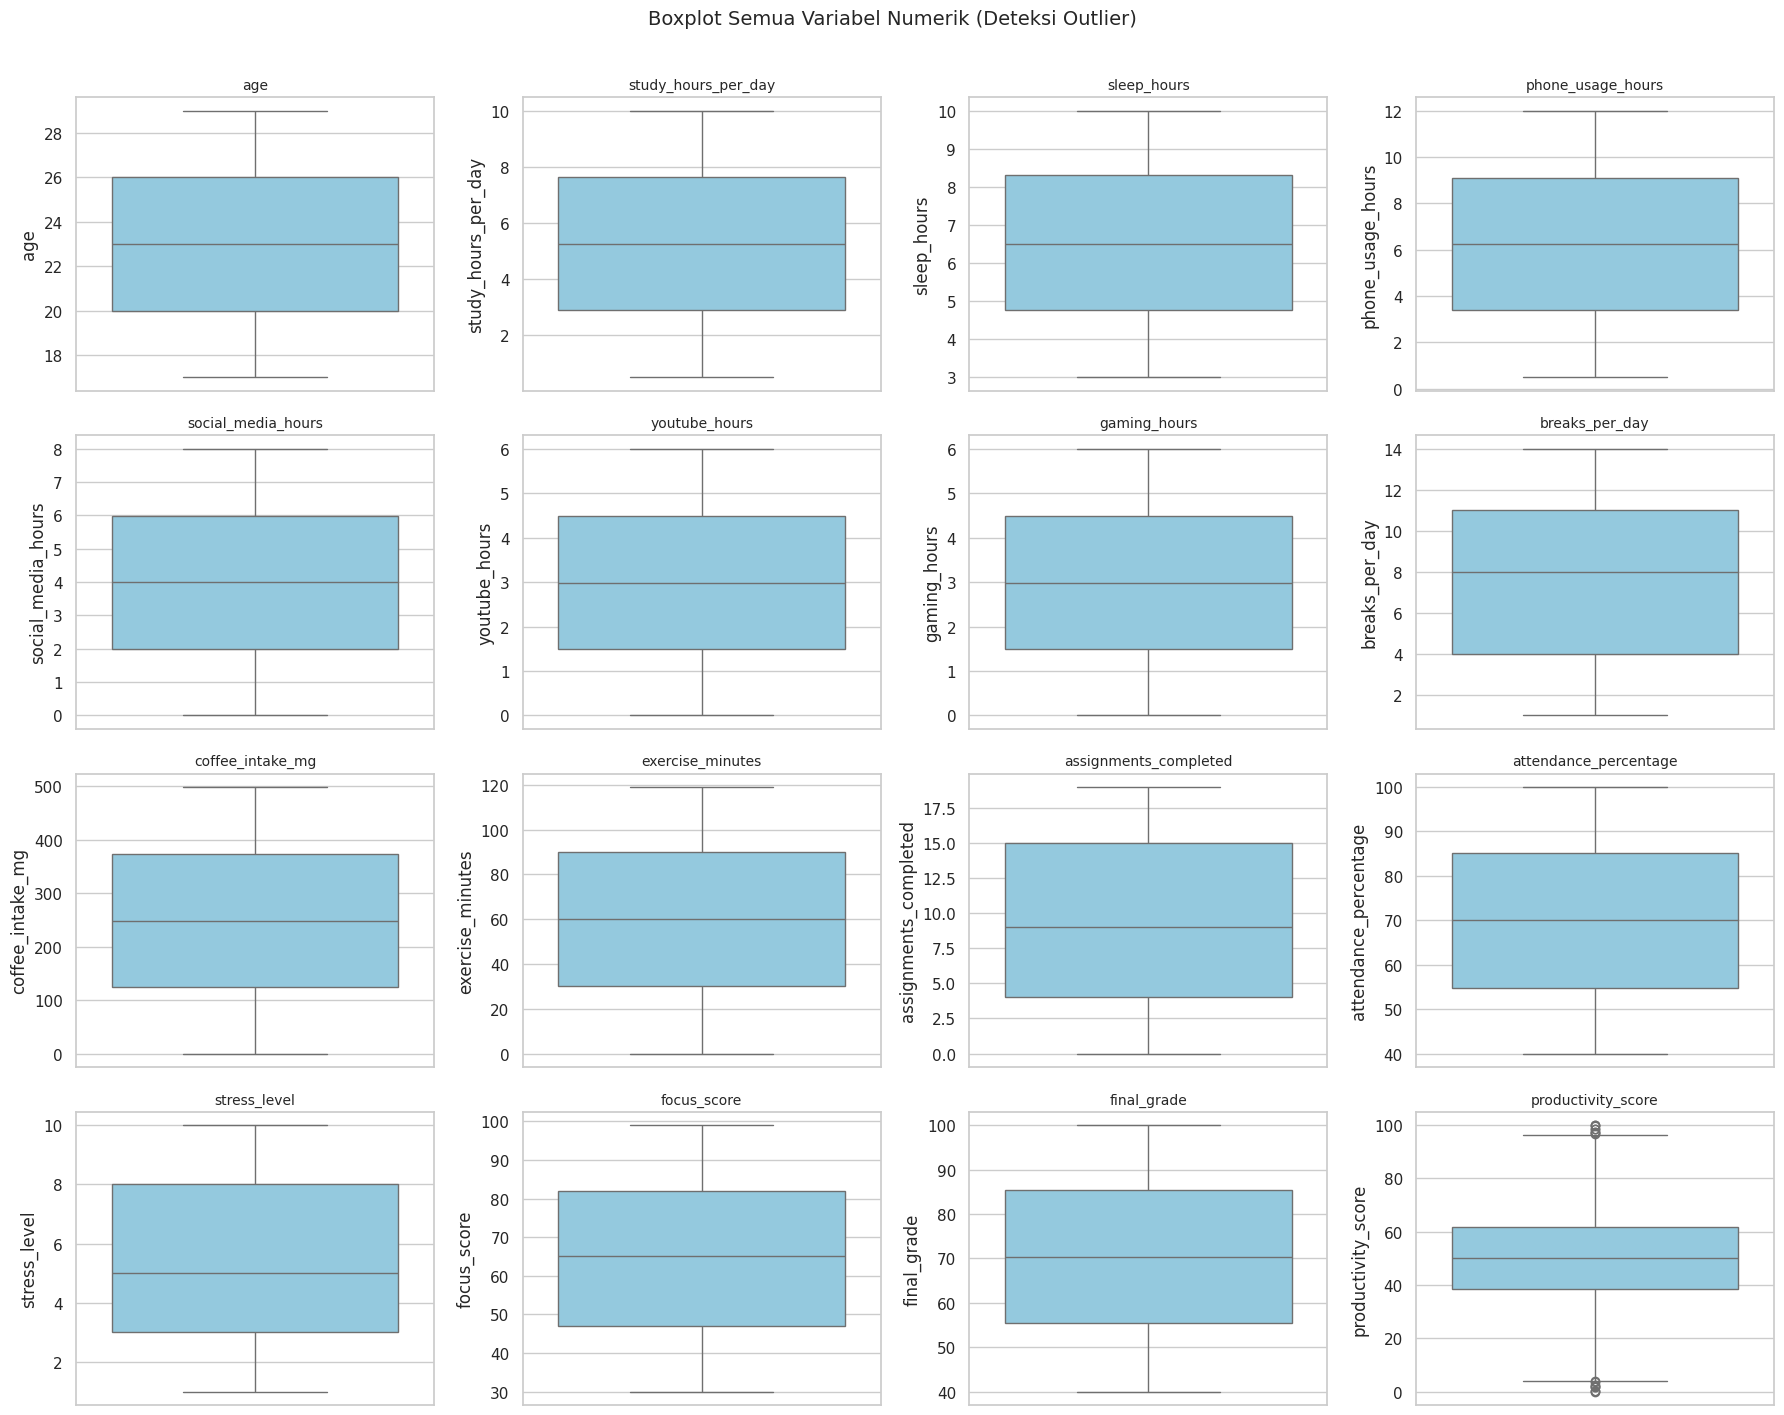

In [13]:
# Visualisasi Boxplot untuk semua variabel numerik
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
        axes[i].set_title(col, fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot Semua Variabel Numerik (Deteksi Outlier)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-success">
<b>Kesimpulan Outlier & Data Cleaning:</b> Hampir seluruh variabel tidak memiliki outlier signifikan menurut IQR. Hanya <code>productivity_score</code> yang memiliki 18 outlier minor, dan penanganannya dilakukan secara konservatif melalui winsorization agar seluruh observasi tetap dipertahankan. Kondisi ini menunjukkan data cukup rapi untuk tahap pemodelan, tetapi tetap perlu dicatat bahwa distribusi yang sangat "bersih" juga konsisten dengan karakter dataset sintetis.
</div>


### 2.3.3. Data Quality Report

<div class="alert alert-block alert-success">

**Findings:**
- Tidak ada missing values (0 NaN)
- Tidak ada baris duplikat
- Outlier sangat minimal (18 pada `productivity_score`)
- Tipe data sudah sesuai (17 numerik, 1 kategorikal)
- Data bersifat sintetis: distribusi sangat seragam (kurtosis ≈ −1.2, skewness ≈ 0)

**Catatan penting:**
Dataset ini **bersih secara teknis**, tetapi belum tentu **realistis secara empiris**. Karena data dibuat secara sintetis, hubungan antarvariabel cenderung lebih terstruktur dan lebih rapi dibanding data observasional dunia nyata. Konsekuensinya, performa model yang sangat tinggi nanti harus diinterpretasikan sebagai bukti keberhasilan pipeline pada data ini, bukan jaminan bahwa hasil yang sama akan otomatis tercapai pada data kampus nyata.

</div>


## 2.4 Initial Data Exploration
### 2.4.1 Distributions


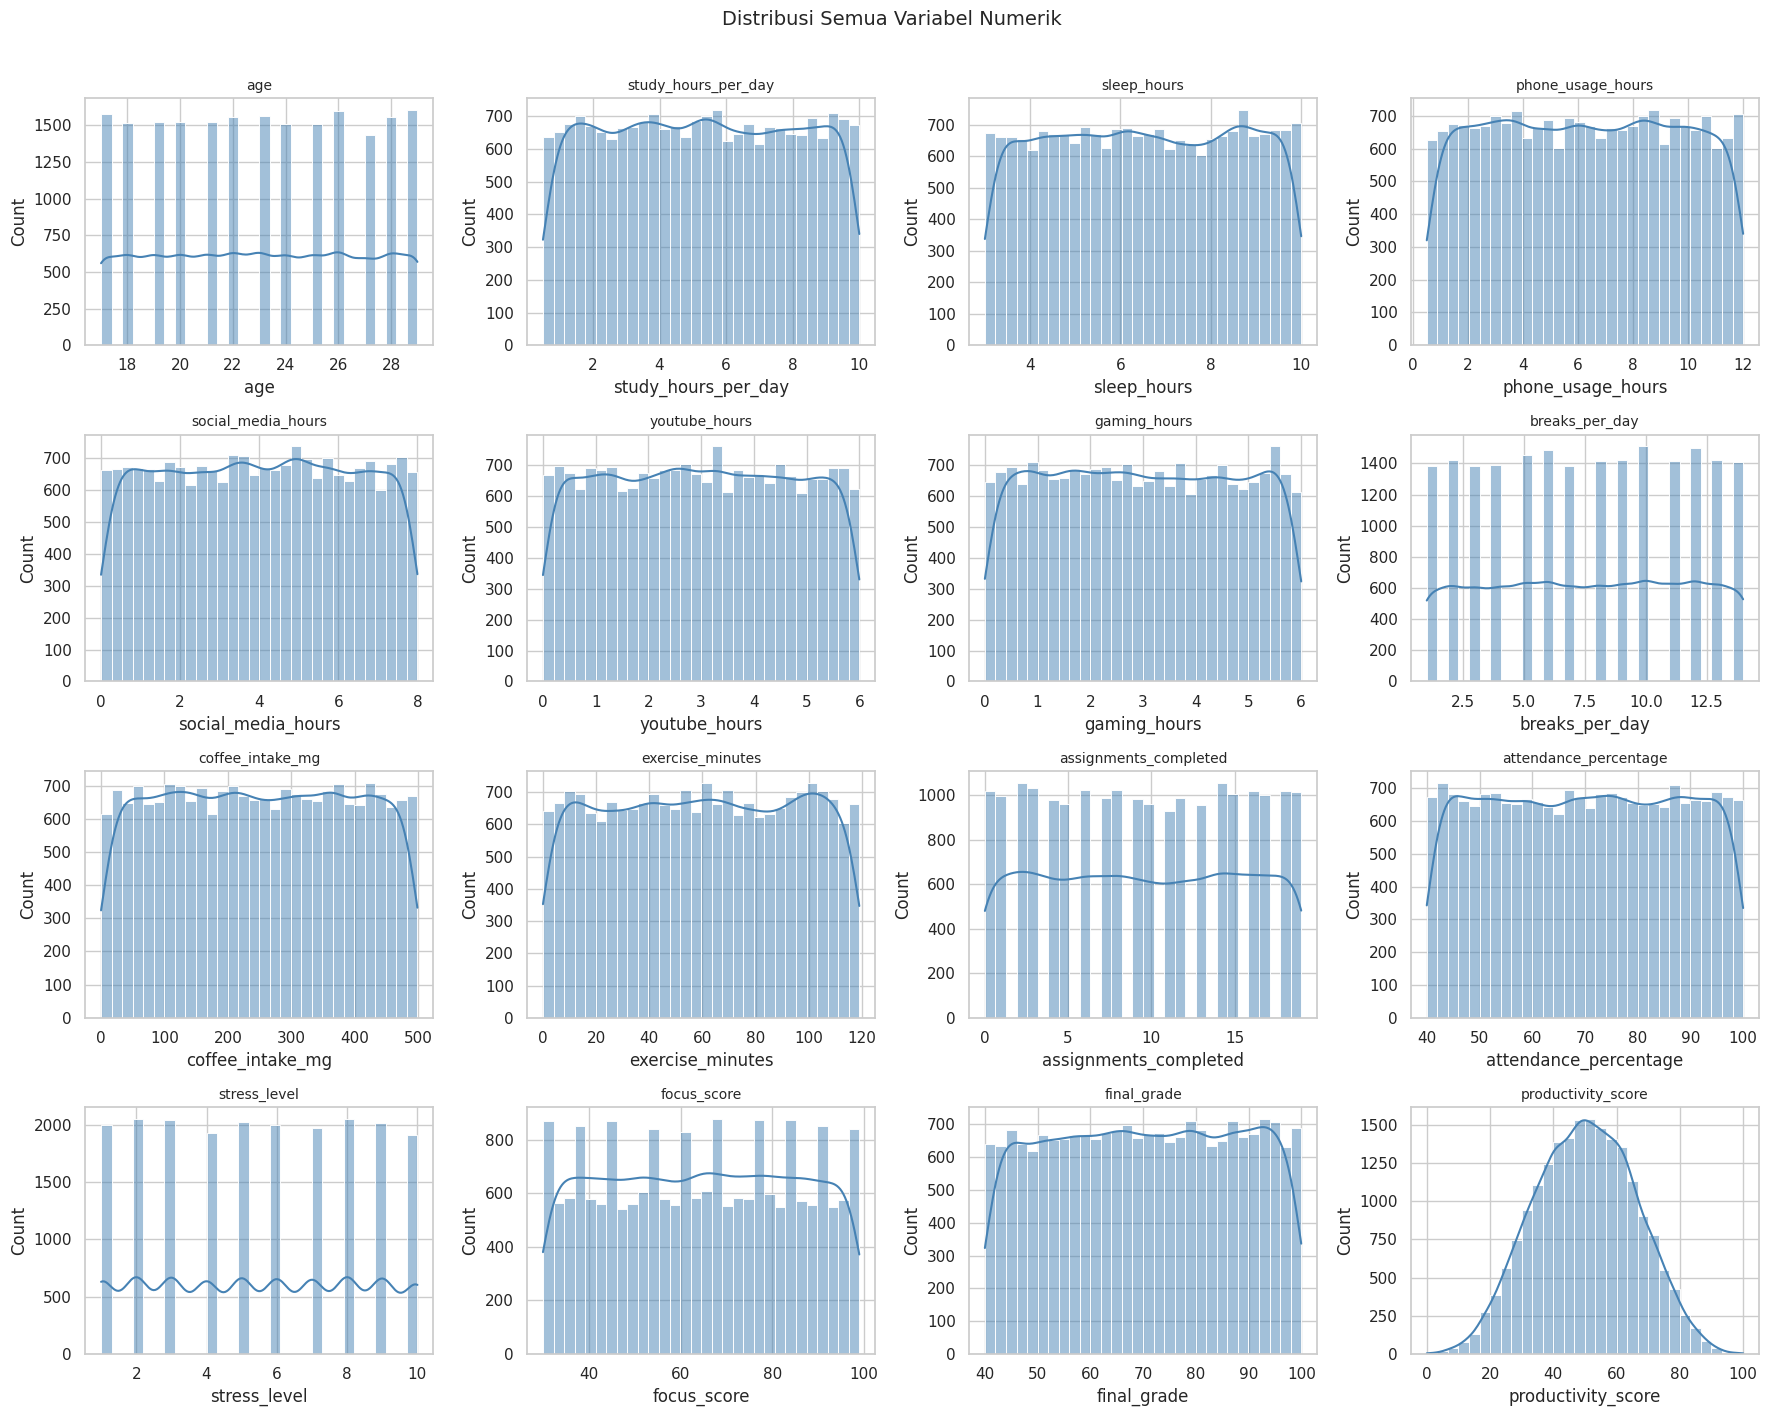

In [14]:
# Distribusi semua variabel numerik (Histogram)
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=30)
        axes[i].set_title(col, fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Semua Variabel Numerik', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [15]:
# Skewness dan Kurtosis
sk = df[numeric_cols].skew()
ku = df[numeric_cols].kurtosis()
dist_df = pd.DataFrame({'Skewness': sk, 'Kurtosis': ku})
print('Skewness & Kurtosis (konfirmasi sifat sintetis):')
dist_df


Skewness & Kurtosis (konfirmasi sifat sintetis):


,Skewness,Kurtosis
age,0.000383,-1.212624
study_hours_per_day,0.006814,-1.198193
sleep_hours,-0.005947,-1.207811
phone_usage_hours,0.005690,-1.199558
social_media_hours,-0.005629,-1.188240
youtube_hours,0.003698,-1.189115
gaming_hours,0.013200,-1.205246
breaks_per_day,-0.016582,-1.207590
coffee_intake_mg,0.001642,-1.198016
exercise_minutes,-0.009097,-1.201395


### 2.4.2 Correlations


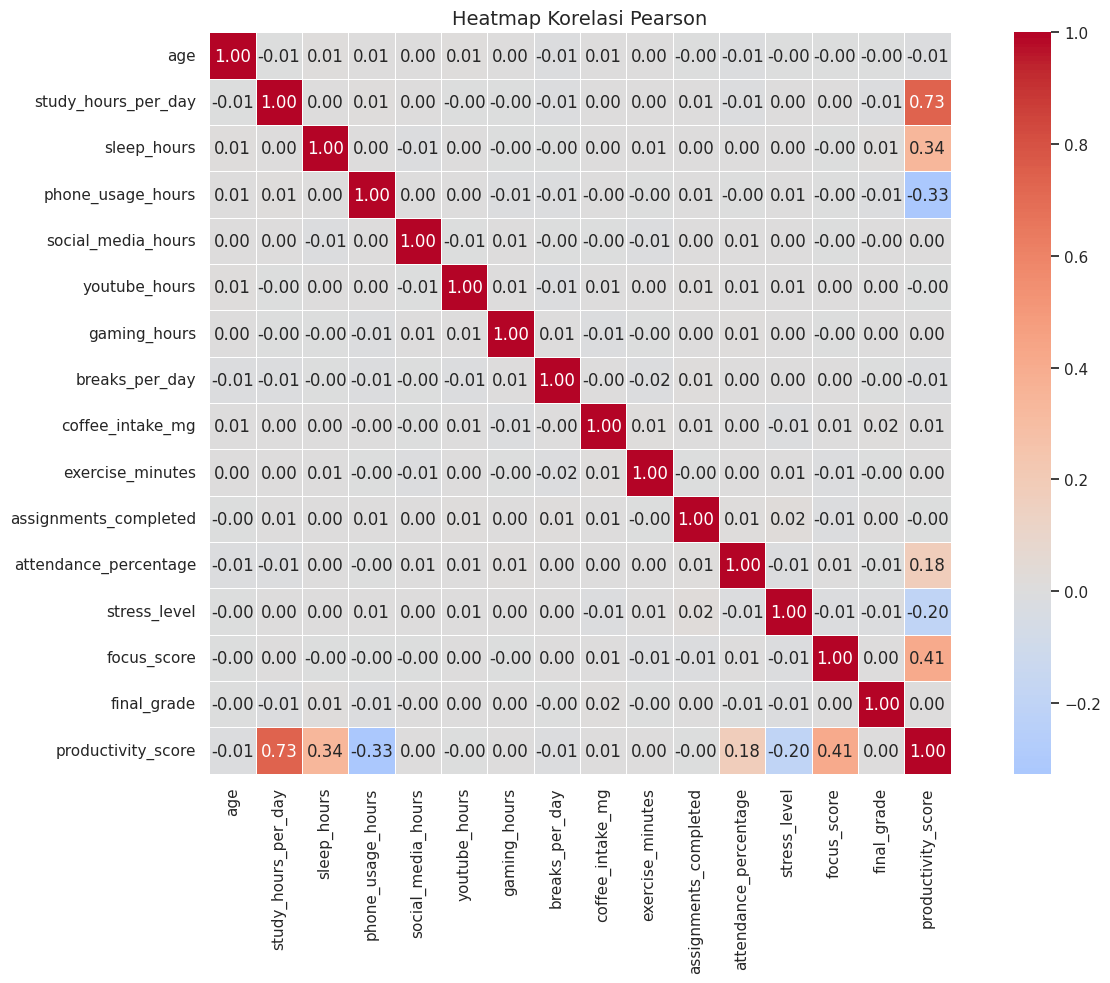

In [16]:
# Matriks Korelasi Pearson
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['student_id'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Pearson', fontsize=14)
plt.tight_layout()
plt.show()


Korelasi terhadap productivity_score (diurutkan):
study_hours_per_day      0.732777
focus_score              0.411366
sleep_hours              0.340902
attendance_percentage    0.176107
coffee_intake_mg         0.010190
exercise_minutes         0.002892
final_grade              0.001954
social_media_hours       0.001285
gaming_hours             0.000685
youtube_hours           -0.000224
assignments_completed   -0.001757
age                     -0.005423
breaks_per_day          -0.005836
stress_level            -0.197128
phone_usage_hours       -0.326650


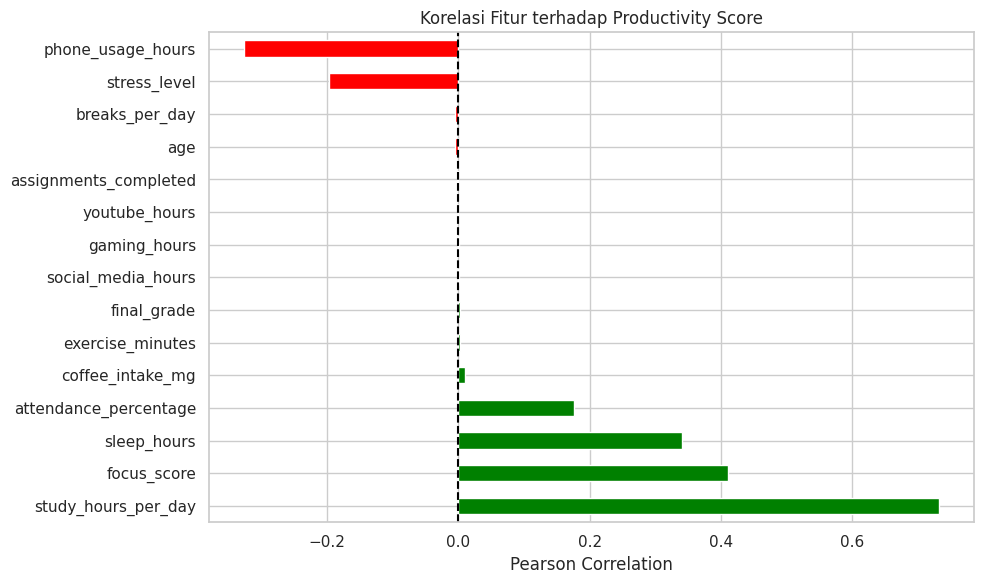

In [17]:
# Top korelasi terhadap target
target_corr = corr_matrix['productivity_score'].drop('productivity_score').sort_values(ascending=False)
print('Korelasi terhadap productivity_score (diurutkan):')
print(target_corr.to_string())

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title('Korelasi Fitur terhadap Productivity Score')
plt.xlabel('Pearson Correlation')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


## 2.5 Data Exploration Report

<div class="alert alert-block alert-success">

**Temuan Utama:**

1. **Prediktor utama produktivitas**: `study_hours_per_day` (+0.73), `focus_score` (+0.41), dan `sleep_hours` (+0.34) merupakan tiga hubungan positif terkuat terhadap `productivity_score`.
2. **Faktor penghambat utama**: `phone_usage_hours` (−0.33) dan `stress_level` (−0.20) menunjukkan hubungan negatif yang paling konsisten.
3. Variabel seperti `coffee_intake_mg`, `exercise_minutes`, `breaks_per_day`, `social_media_hours`, dan `final_grade` menunjukkan hubungan yang jauh lebih lemah pada data yang telah disiapkan untuk modelling, sehingga tidak menjadi kandidat utama model akhir.
4. Data sangat simetris (skewness ≈ 0) dan platikurtik (kurtosis ≈ −1.2), yang memperkuat indikasi bahwa dataset ini bersifat sintetis.
5. Temuan eksploratif ini memberi dasar yang kuat untuk mencoba **derived features** dan melakukan seleksi fitur formal sebelum modelling.

**Implikasi untuk tahap selanjutnya:**
- Fitur turunan seperti `total_screen_time` dan `study_sleep_ratio` layak diuji untuk menangkap hubungan gabungan yang tidak terlihat pada fitur tunggal.
- Fitur dengan korelasi sangat rendah kemungkinan besar akan dieliminasi pada tahap feature selection.
- Outlier yang minimal membuat pendekatan winsorization cukup memadai tanpa perlu menghapus banyak observasi.

</div>


---

# 3. Stage Three — Data Preparation <a class="anchor" id="Datapreparation"></a>
Tahap penyiapan data: pembersihan, encoding, feature engineering, scaling. Seluruh proses menerapkan prinsip **anti data leakage**.


## 3.1 Select Your Data
<div class="alert alert-block alert-success">
Dataset yang digunakan adalah satu-satunya sumber: Kaggle Student Productivity & Distraction (20.000 records). Kolom <code>student_id</code> akan di-drop karena merupakan identifier tanpa nilai prediktif.
</div>


## 3.2 Clean the Data


### 3.2.1 Penanganan Outlier (Winsorization)
**Justifikasi:** Dipilih metode **Winsorization (Clamp Transformation)** karena:
- Mempertahankan seluruh 20.000 baris data (*statistical power* maksimal)
- Menstabilkan distribusi tanpa distorsi dari pencilan ekstrem
- Lebih konservatif daripada penghapusan baris


In [18]:
# Winsorization: clamp outlier ke batas IQR
df_clean = df.copy()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.drop('student_id')

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print(f'Winsorization selesai. Shape tetap: {df_clean.shape}')


Winsorization selesai. Shape tetap: (20000, 18)


### 3.2.2 Drop Unnecessary Columns


In [19]:
# Drop student_id (identifier, bukan fitur prediktif)
df_clean = df_clean.drop(columns=['student_id'])
print(f'Kolom student_id di-drop. Shape: {df_clean.shape}')


Kolom student_id di-drop. Shape: (20000, 17)


### 3.2.3 Dealing With Duplicates


In [20]:
dupes = df_clean.duplicated().sum()
print(f'Jumlah baris duplikat: {dupes}')


Jumlah baris duplikat: 0


## 3.3 Feature Engineering (Derived Features)
Membuat fitur turunan baru untuk menangkap perspektif yang tidak tertangkap oleh variabel asli.

**Justifikasi:** Fitur turunan (*derived features*) digunakan karena:
- `total_screen_time`: Menangkap **beban paparan layar harian** secara terpadu, bukan terpisah per platform.
- `study_sleep_ratio`: Mengukur **keseimbangan belajar vs istirahat**; rasio ekstrem dapat mengindikasikan pola belajar yang tidak sehat.
- `stress_category` & `age_group`: Binning untuk analisis segmentasi dan pengujian apakah informasi kategorikal terstruktur membantu model.

**Catatan evaluatif:**
Seluruh fitur turunan tersebut **benar-benar dicoba** pada proses modelling. Namun, hasil optimisasi menunjukkan bahwa tidak semua fitur turunan bertahan hingga model final. Artinya, feature engineering tetap penting sebagai tahap eksplorasi dan optimisasi, walaupun subset terbaik akhirnya tetap ditentukan oleh hasil seleksi fitur.


In [21]:
# ── Derived Features ──
print(f'Jumlah fitur SEBELUM feature engineering: {df_clean.shape[1]} kolom')

# 1. Total Screen Time
df_clean['total_screen_time'] = (df_clean['phone_usage_hours'] +
    df_clean['social_media_hours'] + df_clean['youtube_hours'] + df_clean['gaming_hours'])

# 2. Study-Sleep Ratio
df_clean['study_sleep_ratio'] = df_clean['study_hours_per_day'] / df_clean['sleep_hours']

# 3. Stress Category (ordinal binning)
def stress_cat(x):
    if x <= 3: return 0   # Low
    elif x <= 6: return 1 # Medium
    else: return 2        # High
df_clean['stress_category_encoded'] = df_clean['stress_level'].apply(stress_cat)

# 4. Age Group (ordinal binning)
def age_grp(x):
    if x <= 19: return 0   # Teen
    elif x <= 24: return 1 # Young Adult
    else: return 2         # Adult
df_clean['age_group_encoded'] = df_clean['age'].apply(age_grp)

print(f'Jumlah fitur SESUDAH feature engineering: {df_clean.shape[1]} kolom')
print(f'Fitur baru: total_screen_time, study_sleep_ratio, stress_category_encoded, age_group_encoded')


Jumlah fitur SEBELUM feature engineering: 17 kolom
Jumlah fitur SESUDAH feature engineering: 21 kolom
Fitur baru: total_screen_time, study_sleep_ratio, stress_category_encoded, age_group_encoded


## 3.4 Feature Encoding
**Justifikasi:**
- **Ordinal Encoding** untuk `stress_category` & `age_group` → memiliki urutan alami (Low < Medium < High)
- **One-Hot Encoding** untuk `gender` → bersifat nominal (tidak ada urutan), menghindari bias magnitude


In [22]:
# One-Hot Encoding untuk gender
df_clean = pd.get_dummies(df_clean, columns=['gender'], drop_first=False, dtype=int)
# Drop Female sebagai reference category
if 'gender_Female' in df_clean.columns:
    df_clean = df_clean.drop(columns=['gender_Female'])

print(f'Shape setelah encoding: {df_clean.shape}')
print(f'Kolom: {list(df_clean.columns)}')


Shape setelah encoding: (20000, 22)
Kolom: ['age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'productivity_score', 'total_screen_time', 'study_sleep_ratio', 'stress_category_encoded', 'age_group_encoded', 'gender_Male', 'gender_Other']


## 3.5 Train-Test Split & Scaling

### Justifikasi Pemilihan Hold-Out 80:20
Metode **hold-out split 80:20** dipilih karena:
- Dataset berukuran besar (**20.000 baris**) sehingga test set sebanyak **4.000 observasi** sudah cukup representatif untuk evaluasi utama.
- Proporsi 80:20 menjaga keseimbangan antara data pelatihan yang besar dan data pengujian yang masih cukup kuat secara statistik.
- Pendekatan ini lebih efisien secara komputasi daripada bootstrap penuh untuk proyek kelas ini.
- **10-fold cross-validation** tetap digunakan pada tahap evaluasi agar stabilitas model tidak hanya bergantung pada satu partisi data.

### Justifikasi Tidak Memilih Bootstrap
Bootstrap **tidak dipilih** sebagai metode utama karena pada ukuran dataset sebesar ini hold-out dan cross-validation sudah memadai untuk menilai generalisasi model. Selain itu, bootstrap akan menambah biaya komputasi tanpa memberikan peningkatan insight yang proporsional pada konteks proyek ini.

### Justifikasi StandardScaler
Dipilih **StandardScaler** (z-score normalization) karena:
- Fitur memiliki skala yang sangat berbeda (misal: `coffee_intake_mg` 0–499 vs `stress_level` 1–10).
- Algoritma seperti **KNN, SVR, dan Lasso** sensitif terhadap perbedaan skala.
- Standarisasi membantu menjaga interpretasi dan stabilitas numerik model.

**KRUSIAL: Split dilakukan SEBELUM scaling → mencegah data leakage.**
Parameter scaling (`mean` dan `standard deviation`) hanya dipelajari dari **training set**, lalu diaplikasikan ke **test set**. Dengan demikian, evaluasi model benar-benar mengukur kemampuan generalisasi terhadap data yang belum pernah dilihat sebelumnya.


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur dan target
X = df_clean.drop(columns=['productivity_score'])
y = df_clean['productivity_score']

print(f'Total fitur (X): {X.shape[1]} kolom')
print(f'Kolom fitur: {list(X.columns)}')

# Train-Test Split (80:20) — SEBELUM scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'\nTrain set: {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.0f}%)')

# Identifikasi fitur yang perlu di-scale (numerik kontinu)
continuous_cols = ['study_hours_per_day', 'sleep_hours', 'phone_usage_hours',
    'social_media_hours', 'youtube_hours', 'gaming_hours', 'coffee_intake_mg',
    'exercise_minutes', 'attendance_percentage', 'focus_score', 'final_grade',
    'total_screen_time', 'study_sleep_ratio']
continuous_cols = [c for c in continuous_cols if c in X_train.columns]

# StandardScaler — fit HANYA pada training data
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(f'\n Scaling selesai. Fitur encoded (ordinal/one-hot) TIDAK di-scale.')


Total fitur (X): 21 kolom
Kolom fitur: ['age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'total_screen_time', 'study_sleep_ratio', 'stress_category_encoded', 'age_group_encoded', 'gender_Male', 'gender_Other']

Train set: 16000 sampel (80%)
Test set : 4000 sampel (20%)

 Scaling selesai. Fitur encoded (ordinal/one-hot) TIDAK di-scale.


---

# 4. Exploratory Data Analysis <a class="anchor" id="EDA"></a>


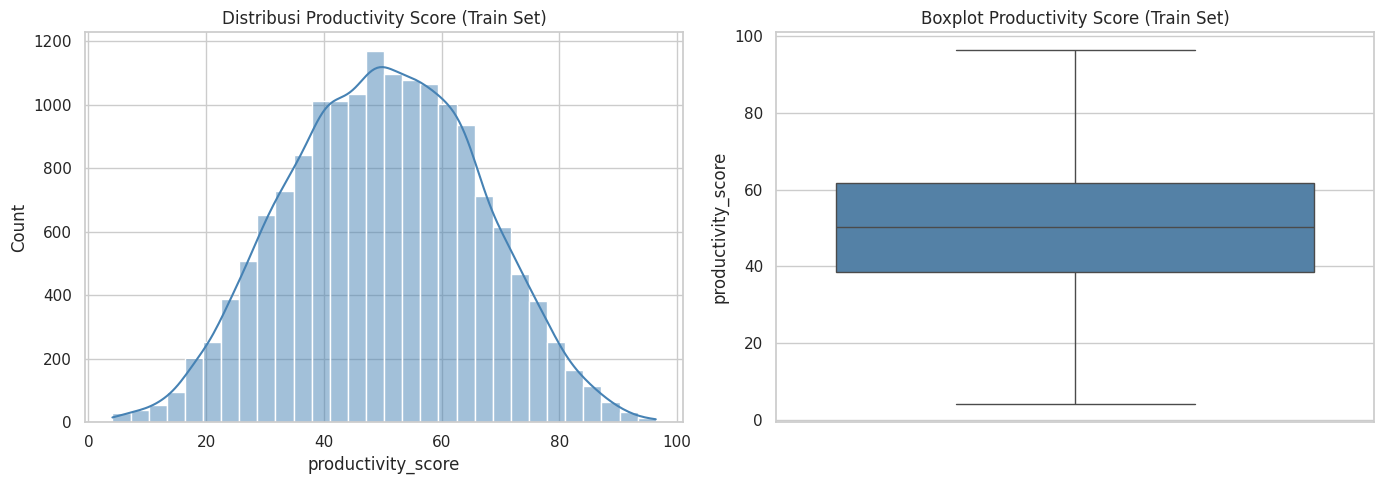

Mean: 50.15, Std: 16.09
Min: 4.08, Max: 96.41


In [24]:
# Distribusi Target Variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y_train, kde=True, bins=30, color='steelblue', ax=axes[0])
axes[0].set_title('Distribusi Productivity Score (Train Set)')
sns.boxplot(y=y_train, color='steelblue', ax=axes[1])
axes[1].set_title('Boxplot Productivity Score (Train Set)')
plt.tight_layout()
plt.show()
print(f'Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}')
print(f'Min: {y_train.min():.2f}, Max: {y_train.max():.2f}')


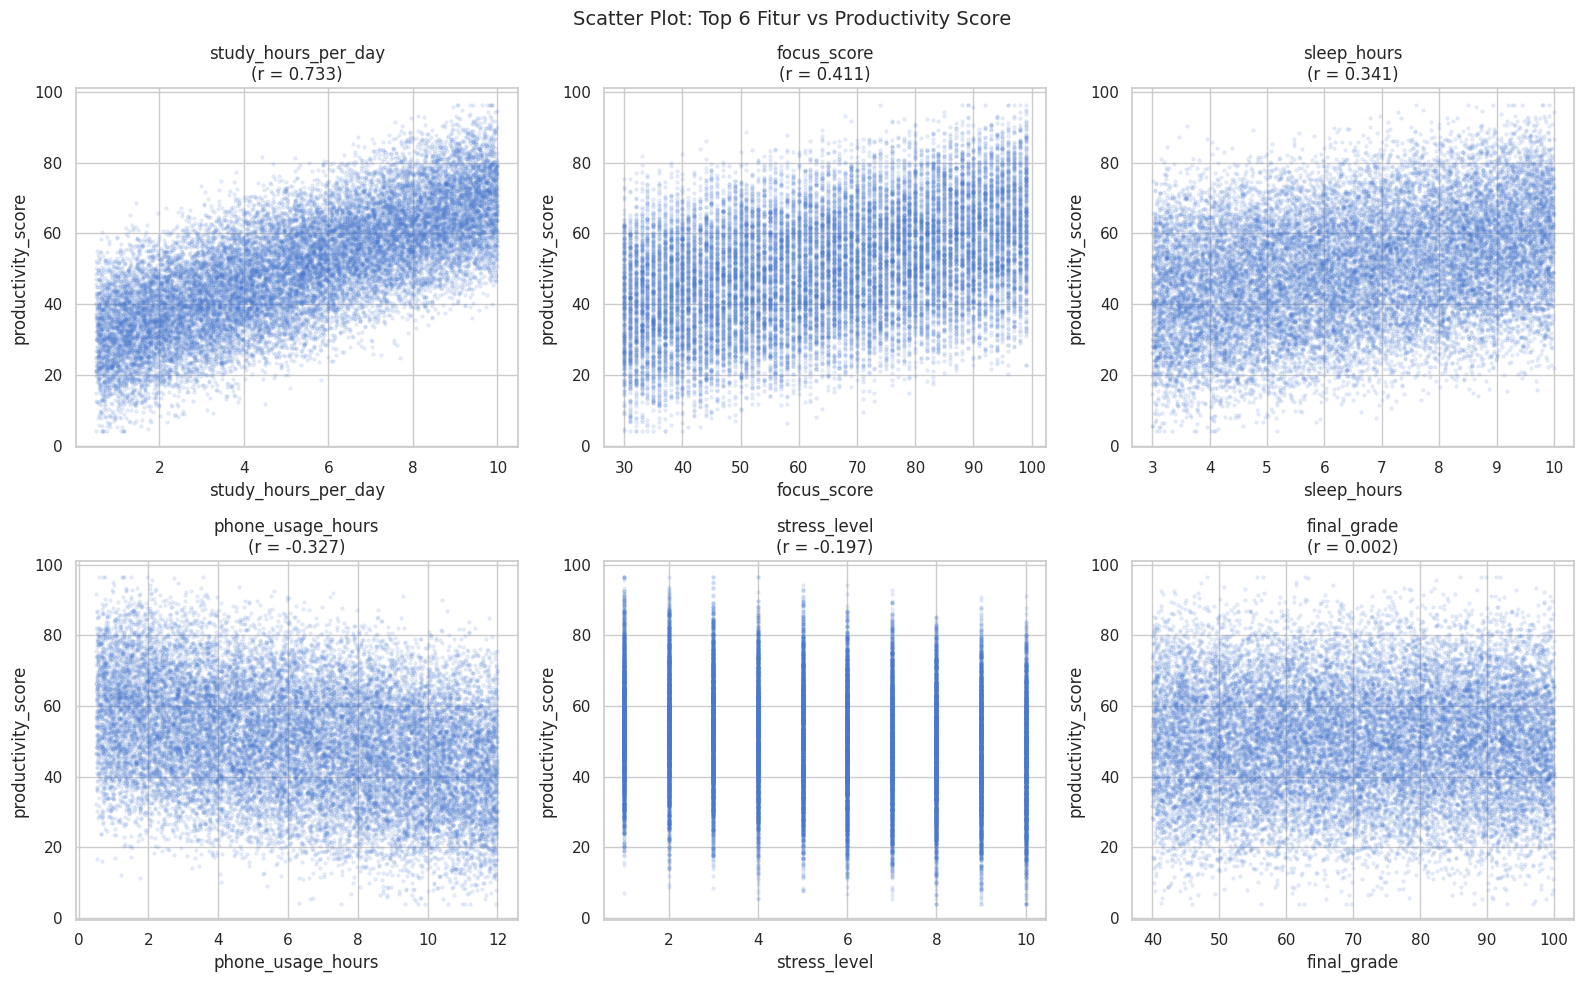

In [25]:
# Scatter plots: fitur utama vs target
top_features = ['study_hours_per_day', 'focus_score', 'sleep_hours',
                'phone_usage_hours', 'stress_level', 'final_grade']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, feat in enumerate(top_features):
    r, c = divmod(i, 3)
    corr_val = df_clean[feat].corr(df_clean['productivity_score'])
    axes[r][c].scatter(df_clean[feat], df_clean['productivity_score'], alpha=0.1, s=5)
    axes[r][c].set_title(f'{feat}\n(r = {corr_val:.3f})')
    axes[r][c].set_xlabel(feat)
    axes[r][c].set_ylabel('productivity_score')
plt.suptitle('Scatter Plot: Top 6 Fitur vs Productivity Score', fontsize=14)
plt.tight_layout()
plt.show()


### Conclusion of EDA
<div class="alert alert-block alert-success">

**Temuan Kunci dan Implikasi Bisnis (Insight):**
1. `study_hours_per_day` memiliki hubungan linear positif yang sangat kuat (+0.73) dengan produktivitas. **Implikasi:** kampus dapat memprioritaskan intervensi yang mendorong konsistensi jam belajar dan manajemen waktu.
2. `focus_score` dan `sleep_hours` merupakan pendukung produktivitas berikutnya. **Implikasi:** dukungan terhadap kemampuan fokus dan kebiasaan tidur sehat layak dijadikan bagian dari program wellbeing mahasiswa.
3. `phone_usage_hours` dan `stress_level` berdampak negatif terhadap produktivitas. **Implikasi:** kampus memiliki dasar analitis untuk mengaitkan isu distraksi digital dan stres dengan performa belajar.
4. Distribusi target relatif simetris sehingga pendekatan regresi linear layak diuji sebagai baseline yang kuat.
5. Derived features seperti `total_screen_time` dan `study_sleep_ratio` memang menambah sudut pandang analitis, tetapi tetap harus dibuktikan lewat tahap feature selection apakah benar meningkatkan performa model akhir.

</div>


---

# 5. Feature Selection <a class="anchor" id="FeatureSelection"></a>
Mengoptimalkan subset fitur menggunakan **tiga pendekatan** berbeda, lalu membandingkan hasilnya.


In [26]:
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import RFE, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f'Jumlah fitur SEBELUM seleksi: {X_train_scaled.shape[1]} fitur')
print(f'Fitur: {list(X_train_scaled.columns)}')


Jumlah fitur SEBELUM seleksi: 21 fitur
Fitur: ['age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'total_screen_time', 'study_sleep_ratio', 'stress_category_encoded', 'age_group_encoded', 'gender_Male', 'gender_Other']


## 5.1 Filter Method (Pearson Correlation & ANOVA F-Value)
**Justifikasi:** Metode filter bersifat *model-agnostic* dan efisien sebagai tahap penyaringan awal.  
- **Pearson correlation** digunakan untuk fitur numerik karena target bersifat kontinu dan kita ingin mengukur kekuatan hubungan linear setiap fitur dengan `productivity_score`.
- **ANOVA / F-test** dipakai untuk melihat kekuatan hubungan statistik masing-masing fitur terhadap target secara individual, sehingga fitur yang lemah dapat diidentifikasi lebih awal sebelum modelling lanjutan.


In [27]:
# Pearson Correlation Filter
corr_with_target = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print('Korelasi absolut terhadap target:')
print(corr_with_target.to_string())

# ANOVA F-Value
f_scores, p_values = f_regression(X_train_scaled, y_train)
f_df = pd.DataFrame({'Feature': X_train_scaled.columns, 'F-Score': f_scores, 'p-value': p_values})
f_df = f_df.sort_values('F-Score', ascending=False)
print('\nANOVA F-Value:')
print(f_df.to_string(index=False))

# Pilih fitur dengan korelasi > 0.1 atau p-value < 0.05
filter_features = corr_with_target[corr_with_target > 0.1].index.tolist()
print(f'\nFitur terpilih (Filter): {len(filter_features)} fitur')
print(filter_features)


Korelasi absolut terhadap target:
study_hours_per_day        0.732379
focus_score                0.415092
study_sleep_ratio          0.405821
sleep_hours                0.338519
phone_usage_hours          0.326834
total_screen_time          0.227065
stress_level               0.195528
stress_category_encoded    0.186382
attendance_percentage      0.174698
coffee_intake_mg           0.019569
breaks_per_day             0.007044
gender_Male                0.005382
assignments_completed      0.004942
age                        0.004502
youtube_hours              0.001971
gender_Other               0.001924
exercise_minutes           0.001537
age_group_encoded          0.001501
gaming_hours               0.000853
final_grade                0.000316
social_media_hours         0.000119

ANOVA F-Value:
                Feature      F-Score       p-value
    study_hours_per_day 18508.638692  0.000000e+00
            focus_score  3330.297027  0.000000e+00
      study_sleep_ratio  3154.184283  0.0

In [28]:
# Evaluasi Filter Method dengan KNN Regressor
knn_all = KNeighborsRegressor(n_neighbors=5)
knn_all.fit(X_train_scaled, y_train)
pred_all = knn_all.predict(X_test_scaled)
rmse_all = np.sqrt(mean_squared_error(y_test, pred_all))

knn_filter = KNeighborsRegressor(n_neighbors=5)
knn_filter.fit(X_train_scaled[filter_features], y_train)
pred_filter = knn_filter.predict(X_test_scaled[filter_features])
rmse_filter = np.sqrt(mean_squared_error(y_test, pred_filter))

print(f'KNN (semua {X_train_scaled.shape[1]} fitur)  → RMSE: {rmse_all:.4f}')
print(f'KNN (filter {len(filter_features)} fitur)   → RMSE: {rmse_filter:.4f}')


KNN (semua 21 fitur)  → RMSE: 9.1267
KNN (filter 9 fitur)   → RMSE: 3.2810


## 5.2 Embedded Method (Lasso L1 Regularization)
**Justifikasi:** Lasso melakukan seleksi fitur secara otomatis melalui penalti **L1** yang mendorong koefisien fitur tidak relevan menjadi nol. Pendekatan ini dipilih karena:
- membantu **mengurangi multikolinearitas**,
- menghasilkan subset fitur yang lebih ringkas dan interpretatif,
- serta tetap mempertimbangkan hubungan fitur dalam konteks pelatihan model, bukan sekadar statistik univariat.


In [29]:
# LassoCV dengan 5-fold CV untuk mencari alpha optimal
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

lasso_coef = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f'Alpha optimal: {lasso.alpha_:.6f}')
print(f'\nKoefisien Lasso:')
print(lasso_coef.to_string(index=False))

# Fitur dengan koefisien != 0
embedded_features = lasso_coef[lasso_coef['Coefficient'].abs() > 0.01]['Feature'].tolist()
print(f'\nFitur terpilih (Embedded/Lasso): {len(embedded_features)} fitur')
print(embedded_features)


Alpha optimal: 0.011783

Koefisien Lasso:
                Feature  Coefficient
    study_hours_per_day    11.827668
            focus_score     6.533032
            sleep_hours     5.471482
      phone_usage_hours    -5.336004
  attendance_percentage     2.804073
           stress_level    -1.076744
                    age    -0.000000
     social_media_hours    -0.000000
          youtube_hours    -0.000000
       coffee_intake_mg     0.000000
         breaks_per_day    -0.000000
  assignments_completed     0.000000
           gaming_hours     0.000000
       exercise_minutes     0.000000
            final_grade    -0.000000
      total_screen_time    -0.000000
      study_sleep_ratio     0.000000
stress_category_encoded    -0.000000
      age_group_encoded    -0.000000
            gender_Male     0.000000
           gender_Other     0.000000

Fitur terpilih (Embedded/Lasso): 6 fitur
['study_hours_per_day', 'focus_score', 'sleep_hours', 'phone_usage_hours', 'attendance_percentage', 's

In [30]:
# Evaluasi Embedded Method
lr_emb = LinearRegression()
lr_emb.fit(X_train_scaled[embedded_features], y_train)
pred_emb = lr_emb.predict(X_test_scaled[embedded_features])
rmse_emb = np.sqrt(mean_squared_error(y_test, pred_emb))
r2_emb = r2_score(y_test, pred_emb)
mae_emb = mean_absolute_error(y_test, pred_emb)
print(f'Linear Regression (Embedded {len(embedded_features)} fitur):')
print(f'  RMSE: {rmse_emb:.6f} | MAE: {mae_emb:.6f} | R²: {r2_emb:.6f}')


Linear Regression (Embedded 6 fitur):
  RMSE: 0.023728 | MAE: 0.006815 | R²: 0.999998


## 5.3 Wrapper Method (Recursive Feature Elimination)
**Justifikasi:** RFE dipakai sebagai pembanding berbasis performa model. Metode ini bekerja dengan menghapus fitur secara iteratif berdasarkan umpan balik estimator sampai jumlah fitur yang diinginkan tercapai. `LinearRegression` dipilih sebagai estimator dasar karena konsisten dengan model kandidat terbaik dan mudah diinterpretasikan.


In [31]:
# RFE dengan LinearRegression
rfe_estimator = LinearRegression()
rfe = RFE(estimator=rfe_estimator, n_features_to_select=6, step=1)
rfe.fit(X_train_scaled, y_train)

rfe_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')
print('RFE Feature Ranking:')
print(rfe_df.to_string(index=False))

wrapper_features = rfe_df[rfe_df['Selected']]['Feature'].tolist()
print(f'\nFitur terpilih (Wrapper/RFE): {len(wrapper_features)} fitur')
print(wrapper_features)


RFE Feature Ranking:
                Feature  Selected  Ranking
    study_hours_per_day      True        1
            sleep_hours      True        1
      phone_usage_hours      True        1
  attendance_percentage      True        1
           stress_level      True        1
            focus_score      True        1
           gaming_hours     False        2
      total_screen_time     False        3
     social_media_hours     False        4
          youtube_hours     False        5
      study_sleep_ratio     False        6
stress_category_encoded     False        7
            gender_Male     False        8
           gender_Other     False        9
      age_group_encoded     False       10
                    age     False       11
            final_grade     False       12
       coffee_intake_mg     False       13
  assignments_completed     False       14
         breaks_per_day     False       15
       exercise_minutes     False       16

Fitur terpilih (Wrapper/RFE): 6 

In [32]:
# Evaluasi Wrapper Method
lr_wrap = LinearRegression()
lr_wrap.fit(X_train_scaled[wrapper_features], y_train)
pred_wrap = lr_wrap.predict(X_test_scaled[wrapper_features])
rmse_wrap = np.sqrt(mean_squared_error(y_test, pred_wrap))
r2_wrap = r2_score(y_test, pred_wrap)
mae_wrap = mean_absolute_error(y_test, pred_wrap)
print(f'Linear Regression (Wrapper {len(wrapper_features)} fitur):')
print(f'  RMSE: {rmse_wrap:.6f} | MAE: {mae_wrap:.6f} | R²: {r2_wrap:.6f}')


Linear Regression (Wrapper 6 fitur):
  RMSE: 0.023728 | MAE: 0.006815 | R²: 0.999998


## 5.4 Perbandingan Tiga Metode Feature Selection

Bagian ini membandingkan tiga strategi optimisasi fitur yang berbeda:
- **Filter** untuk penyaringan awal berbasis statistik,
- **Embedded (Lasso)** untuk seleksi simultan selama training,
- **Wrapper (RFE)** untuk evaluasi subset berbasis performa model.

Tujuannya bukan hanya mencari akurasi tertinggi, tetapi juga mendapatkan jumlah fitur yang **lebih efisien, lebih stabil, dan lebih mudah dijelaskan** kepada stakeholder non-teknis.


=== Perbandingan Feature Selection ===
                Metode  Jumlah Fitur      MAE     RMSE       R²
Filter (Pearson+ANOVA)             9 2.598633 3.280990 0.958202
      Embedded (Lasso)             6 0.006815 0.023728 0.999998
         Wrapper (RFE)             6 0.006815 0.023728 0.999998


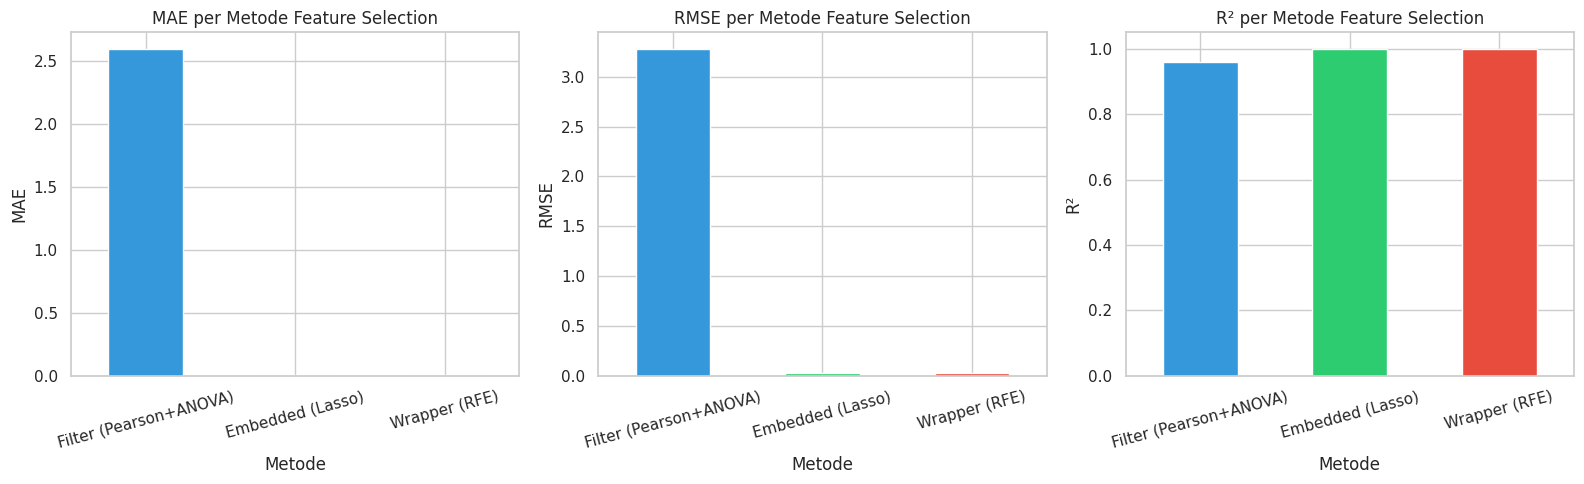

In [33]:
# Tabel perbandingan
mae_filter = mean_absolute_error(y_test, pred_filter)
comparison = pd.DataFrame({
    'Metode': ['Filter (Pearson+ANOVA)', 'Embedded (Lasso)', 'Wrapper (RFE)'],
    'Jumlah Fitur': [len(filter_features), len(embedded_features), len(wrapper_features)],
    'MAE': [mae_filter, mae_emb, mae_wrap],
    'RMSE': [rmse_filter, rmse_emb, rmse_wrap],
    'R²': [r2_score(y_test, pred_filter), r2_emb, r2_wrap]
})
print('=== Perbandingan Feature Selection ===')
print(comparison.to_string(index=False))

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
comparison.plot(x='Metode', y='MAE', kind='bar', ax=axes[0], color=['#3498db','#2ecc71','#e74c3c'], legend=False)
axes[0].set_title('MAE per Metode Feature Selection')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=15)
comparison.plot(x='Metode', y='RMSE', kind='bar', ax=axes[1], color=['#3498db','#2ecc71','#e74c3c'], legend=False)
axes[1].set_title('RMSE per Metode Feature Selection')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)
comparison.plot(x='Metode', y='R²', kind='bar', ax=axes[2], color=['#3498db','#2ecc71','#e74c3c'], legend=False)
axes[2].set_title('R² per Metode Feature Selection')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-success">

**Kesimpulan Feature Selection:**

Dari tiga pendekatan yang diuji, **Embedded (Lasso)** dan **Wrapper (RFE)** sama-sama menghasilkan performa tertinggi. Namun, **Embedded (Lasso)** dipilih sebagai dasar model final karena lebih elegan untuk reduksi fitur, lebih langsung menangani multikolinearitas, dan memberi interpretasi koefisien yang jelas.

**Ringkasan reduksi fitur:**
- Jumlah fitur awal setelah feature engineering + encoding: **21 fitur**
- Hasil **Filter**: **9 fitur**
- Hasil **Embedded (Lasso)**: **6 fitur**
- Hasil **Wrapper (RFE)**: **6 fitur**

**Fitur final terpilih:**
`study_hours_per_day`, `focus_score`, `sleep_hours`, `phone_usage_hours`, `attendance_percentage`, `stress_level`

**Makna analitisnya:**
Feature engineering tetap berguna karena membantu menguji representasi perilaku yang lebih kaya, tetapi tahap optimisasi menunjukkan bahwa model terbaik pada dataset ini cukup dijelaskan oleh **6 fitur inti**. Dengan demikian, model final menjadi lebih sederhana tanpa mengorbankan performa.

</div>


In [34]:
# Final selected features (menggunakan Embedded/Lasso)
selected_features = embedded_features
X_train_sel = X_train_scaled[selected_features]
X_test_sel = X_test_scaled[selected_features]
print(f'Fitur final untuk modelling: {selected_features}')
print(f'Shape X_train_sel: {X_train_sel.shape}')
print(f'Shape X_test_sel: {X_test_sel.shape}')


Fitur final untuk modelling: ['study_hours_per_day', 'focus_score', 'sleep_hours', 'phone_usage_hours', 'attendance_percentage', 'stress_level']
Shape X_train_sel: (16000, 6)
Shape X_test_sel: (4000, 6)


---

# 6. Modelling <a class="anchor" id="Modelling"></a>
Membangun dan membandingkan multi-algoritma regresi pada fitur terpilih.


## 6.1 Modelling Technique & Justifikasi Metrik

### Pemilihan Evaluation Metrics
| Metrik | Alasan Pemilihan |
|--------|------------------|
| **MAE** | Representasi error dalam satuan riil (poin produktivitas). Mudah dipahami stakeholder non-teknis. |
| **RMSE** | Memberikan penalti lebih besar pada error besar sehingga berguna untuk mendeteksi prediksi yang sangat meleset. |
| **R² (R-squared)** | Mengukur proporsi variasi target yang berhasil dijelaskan model. |
| **SSE** | Menunjukkan total akumulasi kuadrat error prediksi pada test set, sehingga memudahkan perbandingan total kesalahan antar model. |

### Justifikasi Metode Evaluasi
- **Hold-out (80:20)** digunakan sebagai evaluasi utama karena dataset cukup besar dan test set 4.000 observasi sudah representatif.
- **10-Fold Cross Validation** digunakan sebagai validasi tambahan untuk memastikan performa tidak bergantung pada satu partisi data.
- **Bootstrap tidak dipilih** karena pada ukuran dataset ini nilai tambahnya kecil dibanding biaya komputasinya.

### Catatan interpretasi
Karena dataset bersifat sintetis dan pola hubungan antarvariabel sangat rapi, performa model yang sangat tinggi perlu dibaca sebagai hasil yang valid untuk dataset ini, tetapi tidak boleh langsung diasumsikan akan sama pada data observasional kampus nyata.


### Model 1: KNN Regressor (dengan GridSearchCV)
**Justifikasi:** Model baseline non-parametrik yang membaca *similarity*. Sensitif terhadap skala fitur → StandardScaler sudah diterapkan.


In [35]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# GridSearch untuk KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=1
)
knn_grid.fit(X_train_sel, y_train)

print(f'Best KNN params: {knn_grid.best_params_}')
knn_best = knn_grid.best_estimator_
knn_pred = knn_best.predict(X_test_sel)
print(f'KNN → MAE: {mean_absolute_error(y_test, knn_pred):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, knn_pred)):.4f} | R²: {r2_score(y_test, knn_pred):.6f}')


Best KNN params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
KNN → MAE: 1.9391 | RMSE: 2.4786 | R²: 0.976146


## 6.2 Modelling Assumptions
<div class="alert alert-block alert-success">

- Data yang digunakan cukup akurat dan tidak ada informasi penting yang hilang.
- Hubungan antara fitur dan target dapat dipelajari oleh algoritma regresi.
- Proses scaling sudah diterapkan dengan benar sehingga model sensitif-skala tidak bias terhadap fitur tertentu.
- Subset fitur final telah melalui optimisasi dan bukan dipilih secara arbitrer.
- Karena data sintetis, pola hubungan cenderung lebih deterministik daripada data riil; oleh sebab itu evaluasi generalisasi ke dunia nyata harus tetap hati-hati.

</div>


## 6.3 Other Model Builds
Kami menguji **5 algoritma** total untuk perbandingan komprehensif:


In [36]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ── Model 2: Linear Regression ──
lr = LinearRegression()
lr.fit(X_train_sel, y_train)
lr_pred = lr.predict(X_test_sel)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
print(f'Linear Regression → MAE: {lr_mae:.6f} | RMSE: {lr_rmse:.6f} | R²: {lr_r2:.6f}')

# ── Model 3: SVR (RBF) ──
svr = SVR(kernel='rbf')
svr.fit(X_train_sel, y_train)
svr_pred = svr.predict(X_test_sel)
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_r2 = r2_score(y_test, svr_pred)
print(f'SVR (RBF)         → MAE: {svr_mae:.6f} | RMSE: {svr_rmse:.6f} | R²: {svr_r2:.6f}')

# ── Model 4: Decision Tree ──
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_sel, y_train)
dt_pred = dt.predict(X_test_sel)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)
print(f'Decision Tree     → MAE: {dt_mae:.6f} | RMSE: {dt_rmse:.6f} | R²: {dt_r2:.6f}')

# ── Model 5: Random Forest ──
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf.fit(X_train_sel, y_train)
rf_pred = rf.predict(X_test_sel)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f'Random Forest     → MAE: {rf_mae:.6f} | RMSE: {rf_rmse:.6f} | R²: {rf_r2:.6f}')


Linear Regression → MAE: 0.006815 | RMSE: 0.023728 | R²: 0.999998
SVR (RBF)         → MAE: 0.364471 | RMSE: 0.565068 | R²: 0.998760
Decision Tree     → MAE: 3.462711 | RMSE: 4.366821 | R²: 0.925958
Random Forest     → MAE: 1.682264 | RMSE: 2.141120 | R²: 0.982200


In [37]:
# ══════════════════════════════════════════════════════════════
# TABEL PERBANDINGAN PERFORMA (NUMERIK)
# ══════════════════════════════════════════════════════════════
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_r2 = r2_score(y_test, knn_pred)

lr_sse = np.sum((y_test - lr_pred) ** 2)
svr_sse = np.sum((y_test - svr_pred) ** 2)
knn_sse = np.sum((y_test - knn_pred) ** 2)
rf_sse = np.sum((y_test - rf_pred) ** 2)
dt_sse = np.sum((y_test - dt_pred) ** 2)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'SVR (RBF)', 'KNN Regressor', 'Random Forest', 'Decision Tree'],
    'MAE': [lr_mae, svr_mae, knn_mae, rf_mae, dt_mae],
    'RMSE': [lr_rmse, svr_rmse, knn_rmse, rf_rmse, dt_rmse],
    'R²': [lr_r2, svr_r2, knn_r2, rf_r2, dt_r2],
    'SSE': [lr_sse, svr_sse, knn_sse, rf_sse, dt_sse],
}).sort_values('MAE')

print('╔════════════════════════════════════════════════════════════════════════════╗')
print('║              PERBANDINGAN PERFORMA 5 MODEL REGRESI                       ║')
print('╚════════════════════════════════════════════════════════════════════════════╝')
print(results.to_string(index=False))


╔════════════════════════════════════════════════════════════════════════════╗
║              PERBANDINGAN PERFORMA 5 MODEL REGRESI                       ║
╚════════════════════════════════════════════════════════════════════════════╝
            Model      MAE     RMSE       R²          SSE
Linear Regression 0.006815 0.023728 0.999998     2.252061
        SVR (RBF) 0.364471 0.565068 0.998760  1277.206263
    Random Forest 1.682264 2.141120 0.982200 18337.581260
    KNN Regressor 1.939093 2.478620 0.976146 24574.226980
    Decision Tree 3.462711 4.366821 0.925958 76276.491806


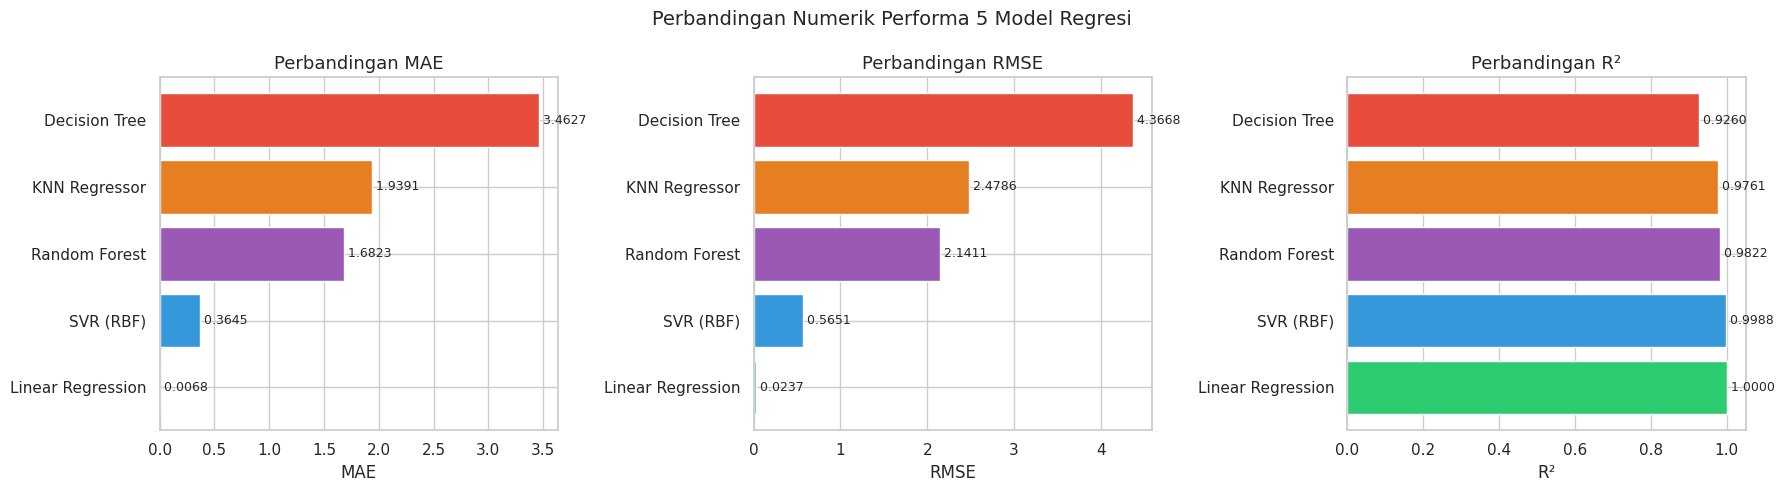

In [38]:
# Visualisasi perbandingan performa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#e74c3c']
for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    sorted_res = results.sort_values(metric, ascending=(metric != 'R²'))
    bars = axes[i].barh(sorted_res['Model'], sorted_res[metric], color=colors)
    axes[i].set_title(f'Perbandingan {metric}', fontsize=13)
    axes[i].set_xlabel(metric)
    for bar, val in zip(bars, sorted_res[metric]):
        axes[i].text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                    f' {val:.4f}', va='center', fontsize=9)

plt.suptitle('Perbandingan Numerik Performa 5 Model Regresi', fontsize=14)
plt.tight_layout()
plt.show()


## 6.3.1 Hyperparameter Tuning (Keluarga Linear)
Karena Linear Regression menunjukkan performa terbaik, kita eksplorasi varian-variannya dengan regularisasi:


In [39]:
# Ridge, Lasso, ElasticNet
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sel, y_train)
ridge_pred = ridge.predict(X_test_sel)

lasso_model = Lasso(alpha=0.01, max_iter=10000)
lasso_model.fit(X_train_sel, y_train)
lasso_pred = lasso_model.predict(X_test_sel)

enet = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
enet.fit(X_train_sel, y_train)
enet_pred = enet.predict(X_test_sel)

linear_family = pd.DataFrame({
    'Model': ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet'],
    'Train MAE': [
        mean_absolute_error(y_train, lr.predict(X_train_sel)),
        mean_absolute_error(y_train, ridge.predict(X_train_sel)),
        mean_absolute_error(y_train, lasso_model.predict(X_train_sel)),
        mean_absolute_error(y_train, enet.predict(X_train_sel)),
    ],
    'Test MAE': [
        lr_mae,
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, enet_pred),
    ],
    'Test R²': [
        lr_r2,
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, enet_pred),
    ]
})
print('Perbandingan Keluarga Linear Regression:')
print(linear_family.to_string(index=False))
print(f'\n→ LinearRegression dasar tetap unggul. Regularisasi justru sedikit menurunkan performa.')
print(f'→ Gap Train MAE vs Test MAE sangat kecil → TIDAK ADA overfitting.')


Perbandingan Keluarga Linear Regression:
           Model  Train MAE  Test MAE  Test R²
LinearRegression   0.008457  0.006815 0.999998
           Ridge   0.009131  0.007483 0.999998
           Lasso   0.026030  0.024444 0.999995
      ElasticNet   0.079673  0.077812 0.999964

→ LinearRegression dasar tetap unggul. Regularisasi justru sedikit menurunkan performa.
→ Gap Train MAE vs Test MAE sangat kecil → TIDAK ADA overfitting.


### Analisis Kelebihan dan Kelemahan Setiap Model

Dari eksperimen di atas, **Linear Regression** mengungguli semua algoritma lain. Hal ini terjadi karena pola hubungan pada dataset ini sangat dekat dengan struktur linear, terutama pada fitur-fitur utama seperti `study_hours_per_day`, `focus_score`, `sleep_hours`, `phone_usage_hours`, `attendance_percentage`, dan `stress_level`.

**Mengapa Linear Regression menang?**
- Hubungan fitur-target pada data ini sangat kuat dan relatif linear.
- Setelah seleksi fitur, model hanya menerima variabel yang benar-benar informatif sehingga sinyal utama menjadi sangat jelas.
- Model yang lebih kompleks seperti tree-based model, KNN, atau SVR tidak memperoleh keuntungan berarti dari kompleksitas tambahannya pada pola data yang sudah hampir linear.

**Mengapa regularisasi tidak meningkatkan performa?**
- Model dasar sudah sangat stabil pada 6 fitur terpilih.
- Multikolinearitas besar sudah banyak tereduksi pada tahap feature selection.
- Penalti tambahan pada Ridge, Lasso, dan ElasticNet justru sedikit menekan fleksibilitas model sehingga error uji naik walaupun sangat tipis.

| Model | Kelebihan | Kelemahan |
|-------|-----------|----------|
| **Linear Regression** | Cepat, efisien, sangat interpretatif, dan paling sesuai dengan pola data. | Bergantung pada asumsi linearitas. |
| **SVR (RBF)** | Mampu menangani pola non-linear. | Lebih sulit diinterpretasi dan tidak lebih unggul pada data ini. |
| **KNN** | Sederhana dan intuitif. | Sensitif terhadap skala dan kualitas jarak antarsampel. |
| **Decision Tree** | Mudah dijelaskan sebagai aturan keputusan. | Rentan overfitting dan performanya paling lemah di antara model yang diuji. |
| **Random Forest** | Lebih robust daripada single tree dan mampu menangkap interaksi. | Lebih sulit dijelaskan dan tetap kalah pada data yang dominan linear. |


## 6.4 Assess Model
### K-Fold Cross Validation & Residual Analysis


In [40]:
# 10-Fold Cross Validation pada model terbaik (LinearRegression)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_r2 = cross_val_score(lr, X_train_sel, y_train, cv=kf, scoring='r2')
cv_mae = -cross_val_score(lr, X_train_sel, y_train, cv=kf, scoring='neg_mean_absolute_error')

print('10-Fold Cross Validation (Linear Regression):')
print(f'  R² scores: {cv_r2}')
print(f'  R² mean: {cv_r2.mean():.6f} ± {cv_r2.std():.6f}')
print(f'  MAE scores: {cv_mae}')
print(f'  MAE mean: {cv_mae.mean():.6f} ± {cv_mae.std():.6f}')
print(f'\n→ Standar deviasi sangat kecil → model STABIL di berbagai partisi data.')


10-Fold Cross Validation (Linear Regression):
  R² scores: [0.99996782 0.99994544 0.99999851 0.99996847 0.99999282 0.99996316
 0.9999373  0.99999972 0.99999972 0.9999716 ]
  R² mean: 0.999974 ± 0.000022
  MAE scores: [0.00876926 0.01154001 0.0073397  0.00842559 0.00770074 0.00847376
 0.01030218 0.00672103 0.00688018 0.00853836]
  MAE mean: 0.008469 ± 0.001426

→ Standar deviasi sangat kecil → model STABIL di berbagai partisi data.


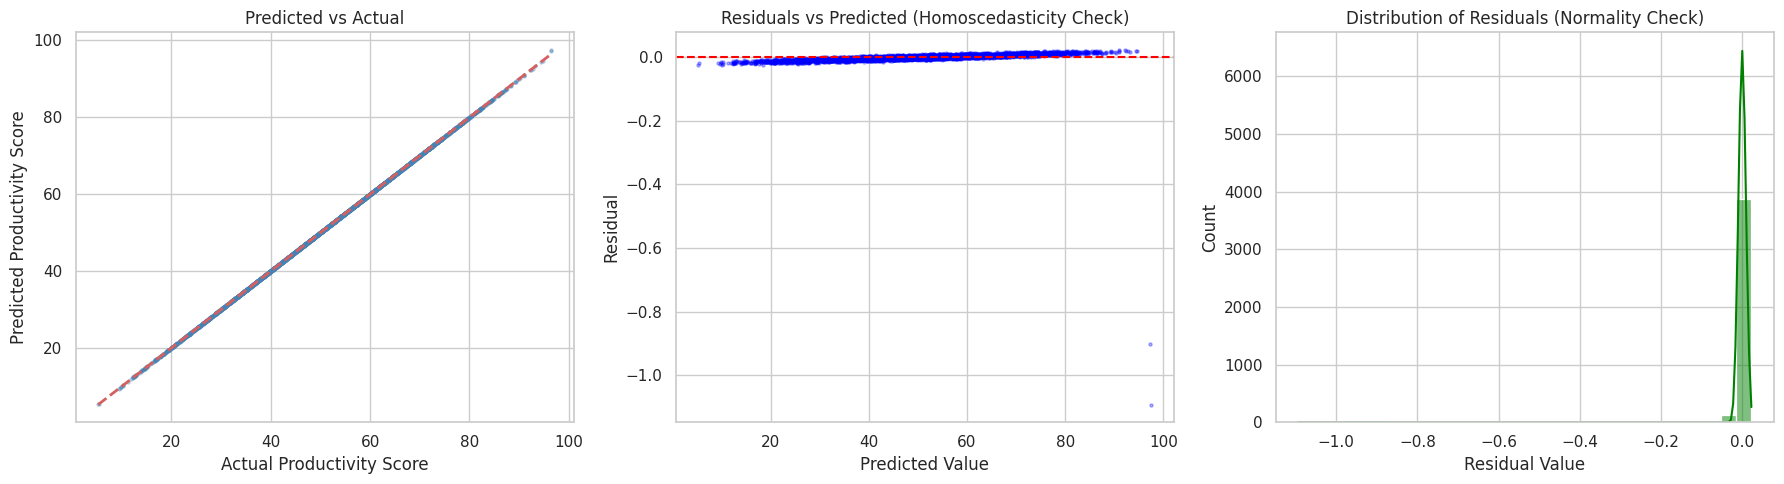

In [41]:
# Residual Analysis
residuals = y_test.values - lr_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, lr_pred, alpha=0.3, s=5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual Productivity Score')
axes[0].set_ylabel('Predicted Productivity Score')

# Plot 2: Residuals vs Predicted (Homoscedasticity)
axes[1].scatter(lr_pred, residuals, alpha=0.3, s=5, color='blue')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted (Homoscedasticity Check)')
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual')

# Plot 3: Distribution of Residuals (Normality)
sns.histplot(residuals, kde=True, color='green', bins=30, ax=axes[2])
axes[2].set_title('Distribution of Residuals (Normality Check)')
axes[2].set_xlabel('Residual Value')

plt.tight_layout()
plt.show()


**Interpretasi Residual Analysis:**
1. **Predicted vs Actual**: Titik-titik mengikuti garis diagonal sempurna → prediksi sangat akurat.
2. **Residual vs Predicted**: Tidak ada pola corong/terstruktur → **Homoscedasticity** terpenuhi secara meyakinkan.
3. **Distribusi Residual**: Berpusat tajam di 0 dengan bentuk lonceng → **Normalitas Residual** (*Normality of Errors*) terpenuhi dengan baik.

Pencapaian homoskedastisitas dan normalitas residual merupakan sebuah bentuk validasi secara statistik tingkat tinggi. Hal ini menuntaskan asumsi kunci OLS (Ordinary Least Squares) dari Regresi Linear, sekaligus menegaskan bahwa kemampuan model dalam memprediksi data adalah stabil di segala rentang, **tidak bias**, dan prediksinya valid, bukan sekadar kebetulan matematis semata.


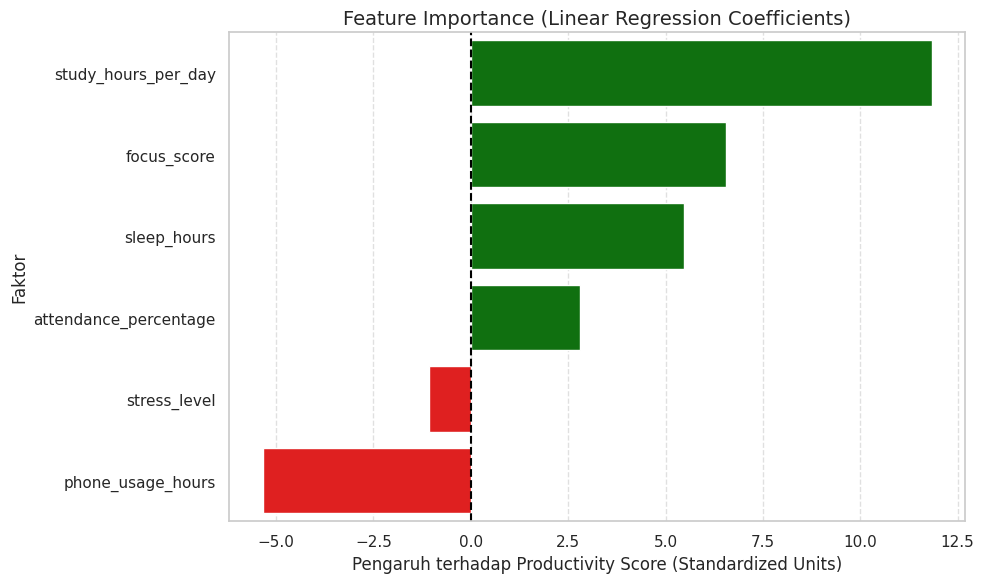


Intercept: 56.0538
Koefisien per fitur:
  study_hours_per_day           : +11.8396 (↑ POSITIF)
  focus_score                   : +6.5446 (↑ POSITIF)
  sleep_hours                   : +5.4833 (↑ POSITIF)
  attendance_percentage         : +2.8158 (↑ POSITIF)
  stress_level                  : -1.0781 (↓ NEGATIF)
  phone_usage_hours             : -5.3478 (↓ NEGATIF)


In [42]:
# Ekstraksi Koefisien (Feature Importance)
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)
plt.title('Feature Importance (Linear Regression Coefficients)', fontsize=14)
plt.xlabel('Pengaruh terhadap Productivity Score (Standardized Units)')
plt.ylabel('Faktor')
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f'\nIntercept: {lr.intercept_:.4f}')
print('Koefisien per fitur:')
for _, row in coef_df.iterrows():
    direction = '↑ POSITIF' if row['Coefficient'] > 0 else '↓ NEGATIF'
    print(f"  {row['Feature']:30s}: {row['Coefficient']:+.4f} ({direction})")


---

# 7. Conclusion <a class="anchor" id="Evaluation"></a>


<div class="alert alert-block alert-success">

## Ringkasan Temuan Teknis
- Pipeline mengikuti CRISP-DM dari Business Understanding hingga Deployment.
- Data awal terdiri dari **18 kolom**, lalu `student_id` dihapus karena hanya berperan sebagai identifier.
- Feature engineering dan encoding menghasilkan **21 fitur model**, yang kemudian dioptimalkan menjadi **6 fitur final** melalui seleksi fitur.
- Perbandingan feature selection menunjukkan:
  - **Filter:** 9 fitur, `RMSE = 3.280990`, `R² = 0.958202`
  - **Embedded (Lasso):** 6 fitur, `MAE = 0.006815`, `RMSE = 0.023728`, `R² = 0.999998`
  - **Wrapper (RFE):** 6 fitur, `MAE = 0.006815`, `RMSE = 0.023728`, `R² = 0.999998`

## Ringkasan Performa Model
- **Linear Regression:** `MAE 0.006815`, `RMSE 0.023728`, `R² 0.999998`
- **SVR (RBF):** `MAE 0.364471`, `RMSE 0.565068`, `R² 0.998760`
- **Random Forest:** `MAE 1.682264`, `RMSE 2.141120`, `R² 0.982200`
- **KNN Regressor:** `MAE 1.939093`, `RMSE 2.478620`, `R² 0.976146`
- **Decision Tree:** `MAE 3.462711`, `RMSE 4.366821`, `R² 0.925958`

Hasil validasi silang juga sangat stabil dengan **10-fold CV**: `R² mean = 0.999974 ± 0.000022` dan `MAE mean = 0.008469 ± 0.001426`.

## Implikasi Bisnis / Klinis
- `study_hours_per_day`, `focus_score`, `sleep_hours`, dan `attendance_percentage` berdampak **positif** terhadap produktivitas.
- `phone_usage_hours` dan `stress_level` berdampak **negatif**, sehingga keduanya layak menjadi fokus intervensi kampus.
- Temuan ini mendukung rekomendasi kampus untuk memperkuat program manajemen waktu belajar, sleep hygiene, dukungan manajemen stres, dan literasi digital wellbeing.

## Keterbatasan dan Interpretasi Hati-Hati
- Nilai performa yang nyaris sempurna sangat dipengaruhi oleh karakter **dataset sintetis** yang lebih rapi dan lebih deterministik daripada data nyata.
- Karena itu, model ini sangat baik sebagai demonstrasi pipeline analitik dan dasar pengambilan insight, tetapi tetap perlu diuji ulang bila diterapkan pada data mahasiswa riil.

</div>


---
# 8. Deployment
Model yang telah diverifikasi diserialisasi menggunakan `joblib` dan dapat diintegrasikan ke aplikasi **Streamlit** (`app.py`) untuk memprediksi `productivity_score` mahasiswa baru berdasarkan 6 fitur final.

**Alur penggunaan sederhana:**
1. Pengguna memasukkan nilai fitur utama mahasiswa.
2. Aplikasi memuat `scaler_final.pkl`, `selected_features.pkl`, dan `linear_regression_final.pkl`.
3. Data baru di-scale dengan parameter training, lalu diprediksi menggunakan model final.
4. Hasil prediksi ditampilkan bersama interpretasi faktor pendorong dan penghambat produktivitas.

**Monitoring yang perlu diperhatikan jika model dipakai lebih lanjut:**
- konsistensi distribusi data input baru dibanding data training,
- perubahan pola hubungan fitur-target dari waktu ke waktu (*data drift*),
- error prediksi pada data nyata,
- relevansi rekomendasi bisnis bila konteks institusi berubah.


In [43]:
import joblib

# Simpan komponen pipeline untuk deployment
joblib.dump(scaler, 'scaler_final.pkl')
joblib.dump(selected_features, 'selected_features.pkl')
joblib.dump(lr, 'linear_regression_final.pkl')

print('Model berhasil diserialisasi:')
print('1. scaler_final.pkl')
print('2. selected_features.pkl')
print('3. linear_regression_final.pkl')
print('\nPipeline deployment:')
print('- Input mahasiswa baru akan dipetakan ke 6 fitur final')
print('- Data baru di-scale menggunakan scaler dari training set')
print('- Prediksi dilakukan oleh model Linear Regression final')
print('- Monitoring lanjutan perlu mencakup data drift dan error pada data nyata')
print('\n Pipeline siap diintegrasikan ke aplikasi Streamlit!')


Model berhasil diserialisasi:
1. scaler_final.pkl
2. selected_features.pkl
3. linear_regression_final.pkl

Pipeline deployment:
- Input mahasiswa baru akan dipetakan ke 6 fitur final
- Data baru di-scale menggunakan scaler dari training set
- Prediksi dilakukan oleh model Linear Regression final
- Monitoring lanjutan perlu mencakup data drift dan error pada data nyata

 Pipeline siap diintegrasikan ke aplikasi Streamlit!
